1. setup ,libraries & helper function

In [1]:
# ==========================================================
# 1. SETUP: LIBRARIES & HELPER FUNCTIONS
# ==========================================================
print("--- Installing Dependencies... ---")
!pip install lightgbm catboost shap plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import plotly.figure_factory as ff

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc, confusion_matrix, classification_report

# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print(" Libraries Imported Successfully.")

# --- DEFINING VISUALIZATION FUNCTION ---
def visualize_performance(y_true, y_pred, y_probs, model_name):
    """Generates Confusion Matrix, ROC Curve, and Metrics Bar Chart"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
    axes[0].set_title(f'Confusion Matrix: {model_name}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_title(f'ROC Curve: {model_name}')
    axes[1].legend(loc="lower right")

    # 3. Metrics Summary
    report = classification_report(y_true, y_pred, output_dict=True)
    metrics = ['precision', 'recall', 'f1-score']
    values = [report['1'][m] for m in metrics] + [report['accuracy']]
    metrics.append('accuracy')
    sns.barplot(x=metrics, y=values, ax=axes[2], palette="viridis")
    for i, v in enumerate(values):
        axes[2].text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    axes[2].set_ylim(0, 1.1)
    axes[2].set_title(f'Key Metrics: {model_name}')

    plt.tight_layout()
    plt.show()


# --- NEW HELPER: INDIVIDUAL MODEL VISUALIZER ---
def evaluate_individual_model(model_name, y_true, y_pred):
    """Prints report and plots Confusion Matrix for a single model"""
    print(f"\n{'='*40}")
    print(f" EVALUATION: {model_name}")
    print(f"{'='*40}")

    # 1. Print Metric Report (Precision, Recall, F1)
    print(classification_report(y_true, y_pred))

    # 2. Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

--- Installing Dependencies... ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00
 Libraries Imported Successfully.


2. Data Pipeline(Load, Clean, Engineer)

--- Step 1: Loading 4 International Cohorts ---
Loaded Cleveland: (303, 15)
Loaded Hungary: (294, 15)
Loaded Switzerland: (123, 15)
Loaded Long Beach VA: (200, 15)

 COMBINED DATASET SIZE: (920, 15)

--- Visualizing Missing Data Patterns ---


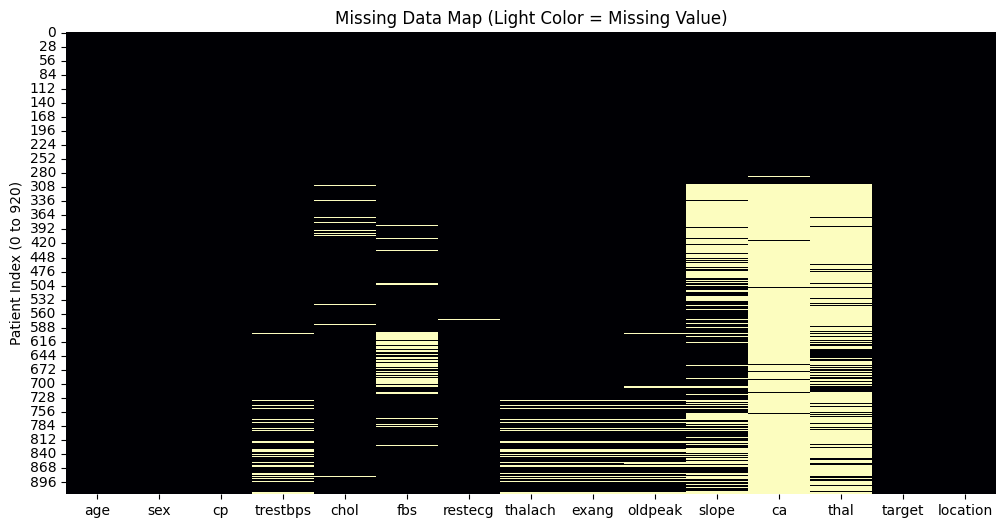


Missing Data Percentages:
ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
exang        5.978261
thalach      5.978261
chol         3.260870
restecg      0.217391
dtype: float64

 DROPPING COLUMNS (>40% Missing): ['ca', 'thal']
--- Applying MICE Imputation to fix remaining gaps ---
 Data Engineering Complete. No missing values.
Final Feature Count: 11
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope  target  
0    3.0       0  
1    2.0       1  
2    2.0       1  
3    3.0       0  
4   

In [2]:
# ==========================================================
# MULTI-CENTER DATA ENGINEERING (CLEVELAND + HUNGARY + SWISS + VA)
# ==========================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

print("--- Step 1: Loading 4 International Cohorts ---")

# Define consistent columns
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# URLs for all 4 datasets
urls = {
    "Cleveland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    "Hungary": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    "Switzerland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data",
    "Long Beach VA": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data"
}

dfs = []

for source, url in urls.items():
    # Load data
    df_temp = pd.read_csv(url, names=cols, na_values='?')

    # Fix Target (Binary)
    df_temp['target'] = (df_temp['target'] > 0).astype(int)

    # Tag the source (Good for analysis later)
    df_temp['location'] = source

    dfs.append(df_temp)
    print(f"Loaded {source}: {df_temp.shape}")

# Combine into one Mega-Dataset
df_mega = pd.concat(dfs, axis=0, ignore_index=True)
print(f"\n COMBINED DATASET SIZE: {df_mega.shape}")

# --- VISUALIZE THE MESS (BEFORE CLEANING) ---
print("\n--- Visualizing Missing Data Patterns ---")
plt.figure(figsize=(12, 6))
sns.heatmap(df_mega.isnull(), cbar=False, cmap='magma')
plt.title("Missing Data Map (Light Color = Missing Value)")
plt.ylabel("Patient Index (0 to 920)")
plt.show()

# --- Step 2: The Amputation (Dropping Unsalvageable Columns) ---
# Calculate missing %
missing_percent = df_mega.isnull().mean() * 100
print("\nMissing Data Percentages:")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

# Rule: Drop columns missing > 40% of data
# (Usually 'ca', 'thal', and 'slope' are lost here because Swiss/VA didn't track them well)
drop_cols = missing_percent[missing_percent > 40].index.tolist()
print(f"\n DROPPING COLUMNS (>40% Missing): {drop_cols}")

df_mega_reduced = df_mega.drop(columns=drop_cols)


# --- Step 3: The Reconstruction (MICE Imputation) ---
print("--- Applying MICE Imputation to fix remaining gaps ---")

# We must separate numeric data from the 'location' tag for imputation
data_numeric = df_mega_reduced.drop(columns=['location', 'target'])
targets = df_mega_reduced['target']

# MICE Imputer
mice = IterativeImputer(max_iter=10, random_state=42)
data_healed = mice.fit_transform(data_numeric)

# Reconstruct DataFrame
df_final = pd.DataFrame(data_healed, columns=data_numeric.columns)
df_final['target'] = targets.values

print(" Data Engineering Complete. No missing values.")
print(f"Final Feature Count: {df_final.shape[1]-1}") # -1 for target
print(df_final.head())

# Define X and y for the next steps
X = df_final.drop('target', axis=1)
y = df_final['target']

3. Preprocessing (Imputation and Scaling)

In [3]:
# ==========================================================
# 3. PREPROCESSING
# ==========================================================
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Impute Missing Values (KNN)
print("--- Imputing Missing Values ---")
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Scale Data (Standardization)
print("--- Scaling Data ---")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X.columns)

print(" Preprocessing Complete.")

--- Imputing Missing Values ---
--- Scaling Data ---
 Preprocessing Complete.


4. Benchmark Training

--- Training 9 Benchmark Models ---

 EVALUATION: Naive Bayes
              precision    recall  f1-score   support

           0       0.70      0.84      0.76        75
           1       0.87      0.75      0.81       109

    accuracy                           0.79       184
   macro avg       0.79      0.80      0.79       184
weighted avg       0.80      0.79      0.79       184



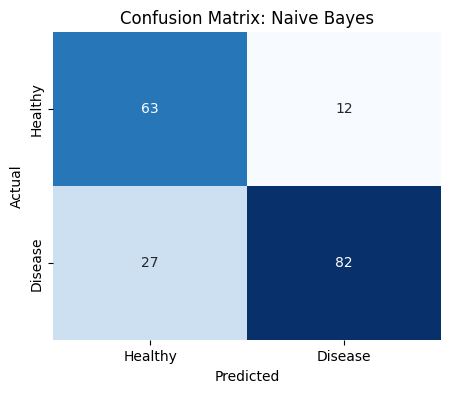


 EVALUATION: Logistic Regression
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        75
           1       0.86      0.82      0.84       109

    accuracy                           0.81       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.81      0.81       184



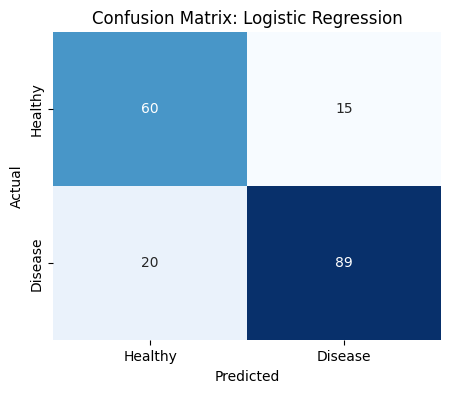


 EVALUATION: KNN
              precision    recall  f1-score   support

           0       0.75      0.85      0.80        75
           1       0.89      0.81      0.85       109

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.83      0.83       184



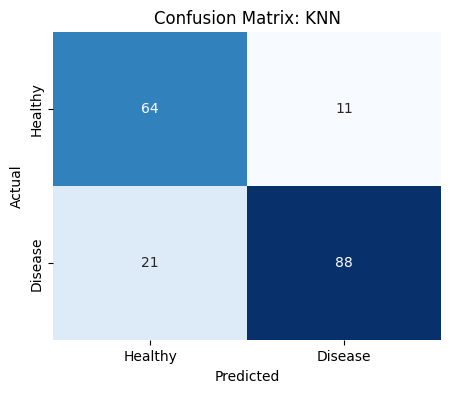


 EVALUATION: SVM
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        75
           1       0.89      0.85      0.87       109

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.85      0.85       184



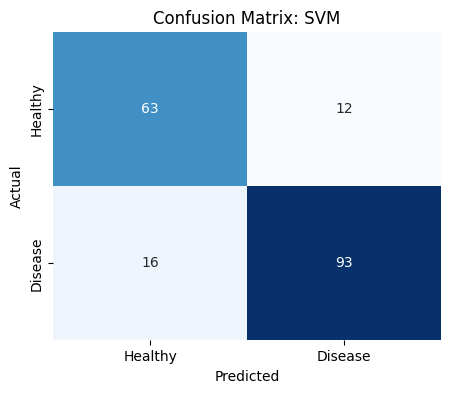


 EVALUATION: Decision Tree
              precision    recall  f1-score   support

           0       0.78      0.85      0.82        75
           1       0.89      0.83      0.86       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.85      0.84      0.84       184



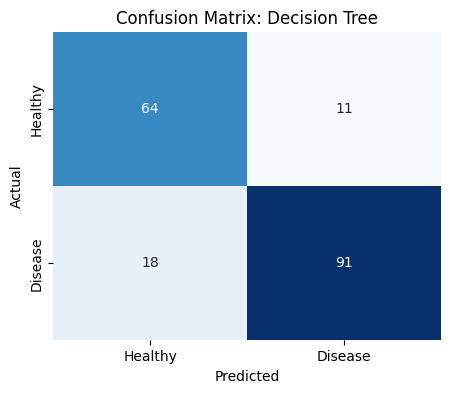


 EVALUATION: Random Forest
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        75
           1       0.88      0.85      0.87       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



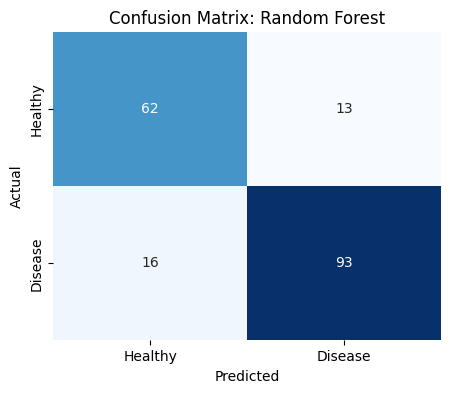

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:40:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 EVALUATION: XGBoost
              precision    recall  f1-score   support

           0       0.77      0.84      0.80        75
           1       0.88      0.83      0.85       109

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.84      0.83      0.83       184



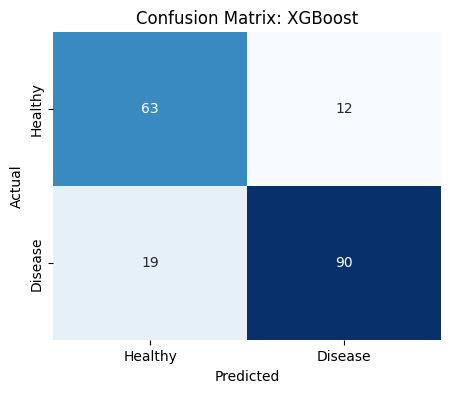


 EVALUATION: LightGBM
              precision    recall  f1-score   support

           0       0.82      0.85      0.84        75
           1       0.90      0.87      0.88       109

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



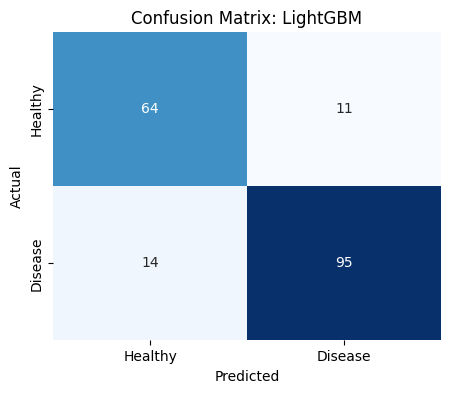


 EVALUATION: CatBoost
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        75
           1       0.88      0.85      0.87       109

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



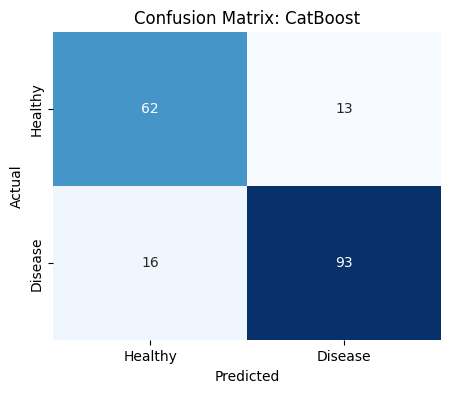

--- Training Deep Learning ANN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

 MODEL LEADERBOARD 
                 Model  Accuracy  F1-Score
7             LightGBM  0.864130  0.883721
3                  SVM  0.847826  0.869159
8             CatBoost  0.842391  0.865116
4        Decision Tree  0.842391  0.862559
5        Random Forest  0.842391  0.865116
6              XGBoost  0.831522  0.853081
2                  KNN  0.826087  0.846154
1  Logistic Regression  0.809783  0.835681
9                  ANN  0.809783  0.830918
0          Naive Bayes  0.788043  0.807882


/tmp/ipykernel_25875/844823485.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=df_results, palette="magma")


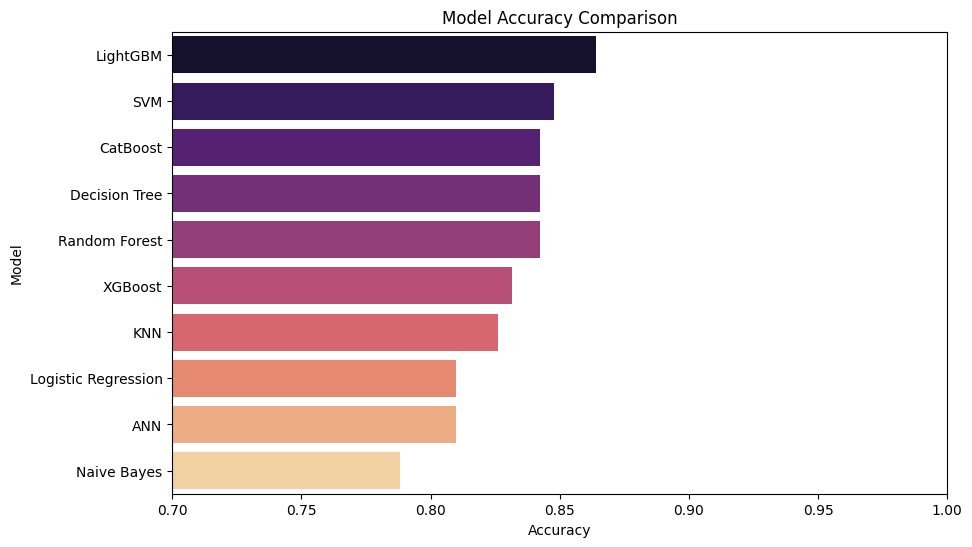

In [4]:
# ==========================================================
# 4. BENCHMARK TRAINING & LEADERBOARD
# ==========================================================
print("--- Training 9 Benchmark Models ---")

models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbosity=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
}

results = []

for name, model in models.items():
    #train
    model.fit(X_train_scaled, y_train)
    #pradict
    y_pred = model.predict(X_test_scaled)

    # VISUALIZE INDIVIDUALLY
    evaluate_individual_model(name, y_test, y_pred)

    #Store metrix for final comparison
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

# Add ANN (Deep Learning)
print("--- Training Deep Learning ANN ---")
ann = Sequential([Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]),
                  Dense(8, activation='relu'), Dropout(0.1), Dense(1, activation='sigmoid')])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_scaled, y_train, epochs=50, batch_size=16, verbose=0)
y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype(int).flatten()
results.append({"Model": "ANN", "Accuracy": accuracy_score(y_test, y_pred_ann), "F1-Score": f1_score(y_test, y_pred_ann)})

# Show Leaderboard
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print("\n MODEL LEADERBOARD ")
print(df_results)

plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=df_results, palette="magma")
plt.title("Model Accuracy Comparison")
plt.xlim(0.7, 1.0)
plt.show()

5. Champion model


--- Initiating Championship Battle ---

 CHALLENGER A: Manual Ensemble (Human Intuition)
 >> Accuracy: 0.8478


/tmp/ipykernel_25875/3929215134.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, ax=axes[2], palette="viridis")


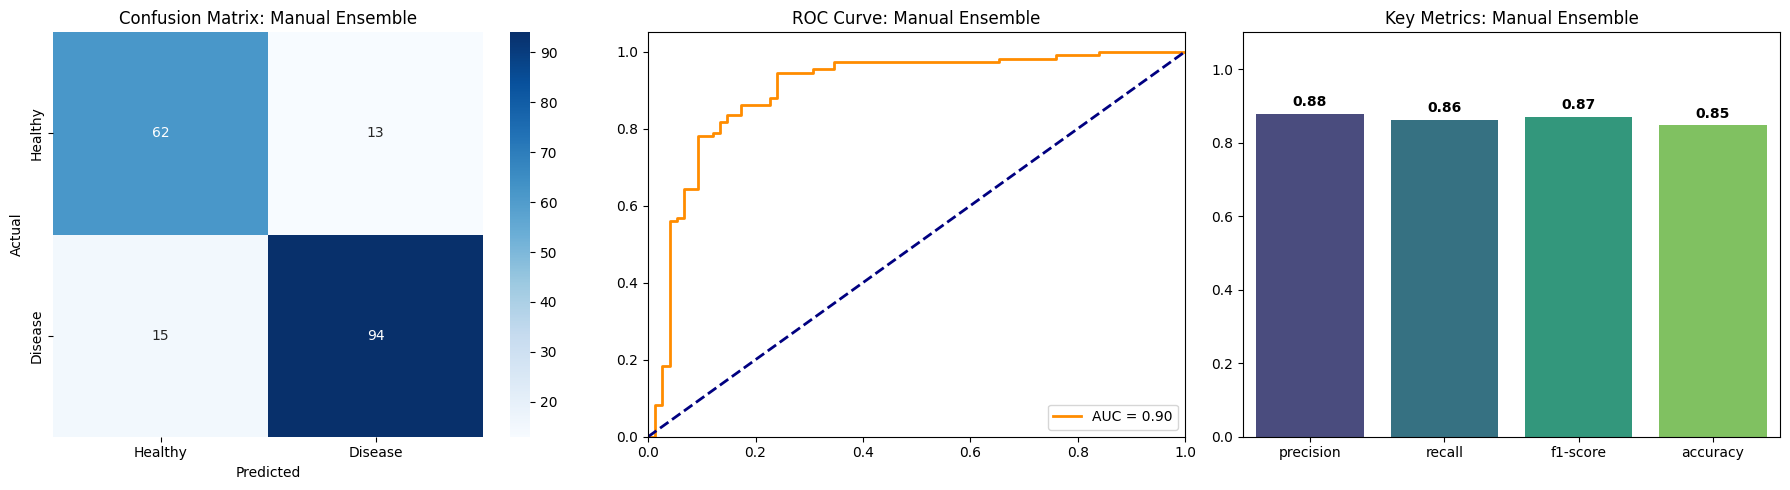


CHALLENGER B: Automated Ensemble (AI Selection)
Auditioning Candidates...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[09:41:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[09:41:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[09:41:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[09:41:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[09:41:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




Selected Top 3: ['Naive Bayes', 'CatBoost', 'Logistic Regression']
 >> Accuracy: 0.8207


/tmp/ipykernel_25875/3929215134.py:67: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




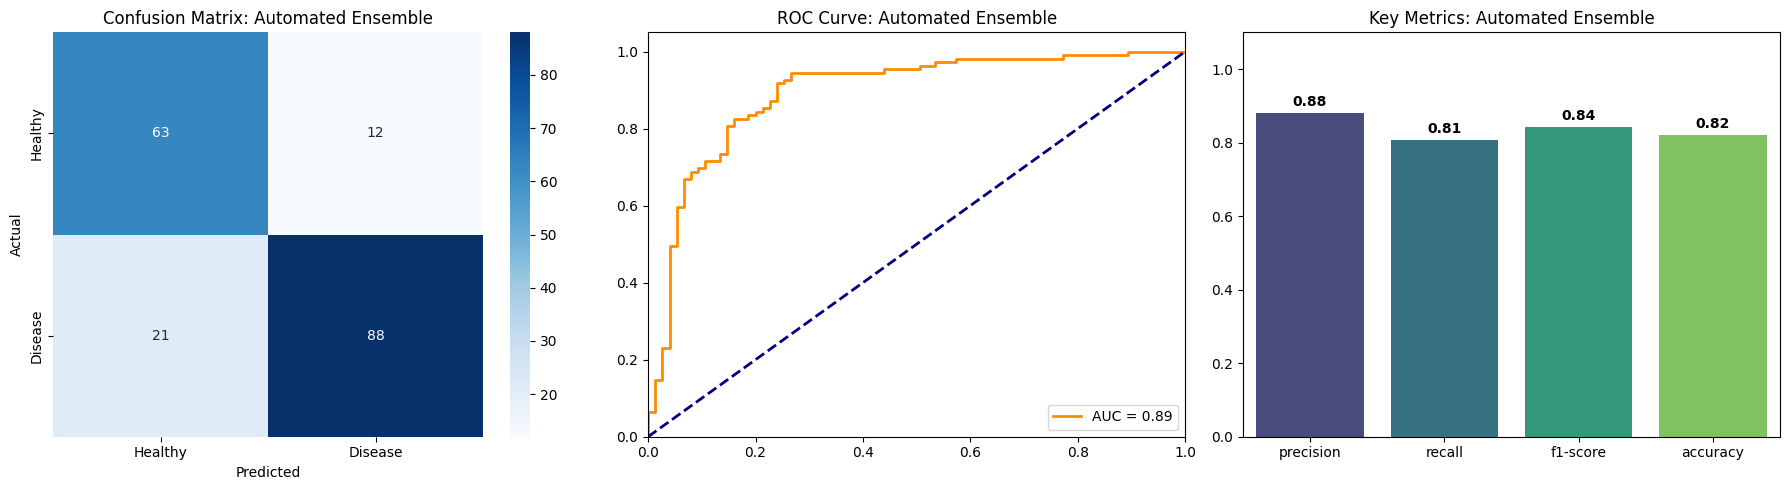


        FINAL VERDICT 
WINNER: Manual Hyper-Boosted Ensemble (Human Intuition)
NOTE: The winner has been saved as 'voting_clf' for the next steps.


/tmp/ipykernel_25875/765008159.py:119: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




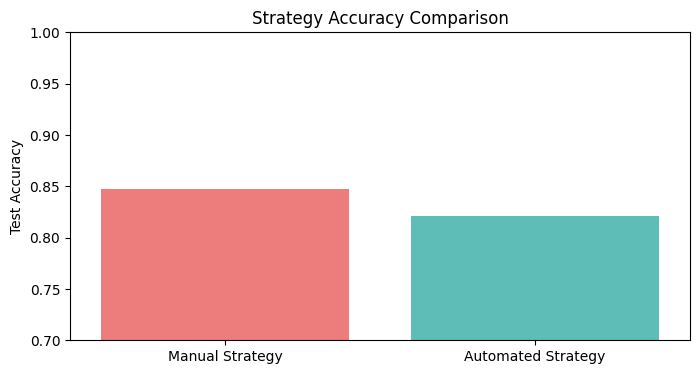

In [5]:
# ==========================================================
# 5. THE ULTIMATE FACE-OFF: MANUAL VS. AUTOMATED ENSEMBLE
# ==========================================================
from sklearn.model_selection import cross_val_score
import plotly.figure_factory as ff

print("--- Initiating Championship Battle ---")

# ---------------------------------------------------------
# CHALLENGER A: THE MANUAL "HYPER-BOOSTED" MODEL
# ---------------------------------------------------------
print("\n" + "="*40)
print(" CHALLENGER A: Manual Ensemble (Human Intuition)")
print("="*40)

svm_tuned = SVC(C=3.0, kernel='rbf', gamma='scale', probability=True, random_state=42)
rf_tuned = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
cat_tuned = CatBoostClassifier(verbose=0, depth=5, iterations=500, learning_rate=0.01, random_state=42)
lr_tuned = LogisticRegression(C=0.5, solver='liblinear', random_state=42)

model_manual = VotingClassifier(
    estimators=[('svm', svm_tuned), ('rf', rf_tuned), ('cat', cat_tuned), ('lr', lr_tuned)],
    voting='soft', weights=[3, 2, 3, 1]
)
model_manual.fit(X_train_scaled, y_train)

# --- VISUALIZE MANUAL MODEL ---
y_pred_man = model_manual.predict(X_test_scaled)
y_probs_man = model_manual.predict_proba(X_test_scaled)[:, 1]
acc_manual = accuracy_score(y_test, y_pred_man)

print(f" >> Accuracy: {acc_manual:.4f}")
visualize_performance(y_test, y_pred_man, y_probs_man, "Manual Ensemble")

# Manual Confidence Plot
hist_data_man = [y_probs_man[y_test == 0], y_probs_man[y_test == 1]]
fig_man = ff.create_distplot(hist_data_man, ['Healthy', 'Disease'], bin_size=0.05, show_hist=False, show_rug=False)
fig_man.update_layout(title_text='Manual Ensemble Confidence', height=400)
fig_man.show()


# ---------------------------------------------------------
# CHALLENGER B: THE AUTOMATED "FULL SPECTRUM" MODEL
# ---------------------------------------------------------
print("\n" + "="*40)
print("CHALLENGER B: Automated Ensemble (AI Selection)")
print("="*40)

candidates = {
    "SVM": SVC(C=3.0, kernel='rbf', gamma='scale', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbosity=-1),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42)
}

# Audition
model_scores = []
print("Auditioning Candidates...")
for name, model in candidates.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    mean_score = cv_scores.mean()
    model_scores.append((name, model, mean_score))

# Select Top 3 & Weights
top_models = sorted(model_scores, key=lambda x: x[2], reverse=True)[:3]
selected_estimators = [(name, model) for name, model, score in top_models]
dynamic_weights = [score**4 for name, model, score in top_models]

print(f"Selected Top 3: {[x[0] for x in top_models]}")

model_auto = VotingClassifier(
    estimators=selected_estimators,
    voting='soft',
    weights=dynamic_weights
)
model_auto.fit(X_train_scaled, y_train)

# --- VISUALIZE AUTOMATED MODEL ---
y_pred_auto = model_auto.predict(X_test_scaled)
y_probs_auto = model_auto.predict_proba(X_test_scaled)[:, 1]
acc_auto = accuracy_score(y_test, y_pred_auto)

print(f" >> Accuracy: {acc_auto:.4f}")
visualize_performance(y_test, y_pred_auto, y_probs_auto, "Automated Ensemble")

# Automated Confidence Plot
hist_data_auto = [y_probs_auto[y_test == 0], y_probs_auto[y_test == 1]]
fig_auto = ff.create_distplot(hist_data_auto, ['Healthy', 'Disease'], bin_size=0.05, show_hist=False, show_rug=False)
fig_auto.update_layout(title_text='Automated Ensemble Confidence', height=400)
fig_auto.show()


# ---------------------------------------------------------
# THE VERDICT
# ---------------------------------------------------------
print("\n" + "="*40)
print("        FINAL VERDICT ")
print("="*40)

if acc_manual >= acc_auto:
    voting_clf = model_manual
    winner_name = "Manual Hyper-Boosted Ensemble"
    print(f"WINNER: {winner_name} (Human Intuition)")
else:
    voting_clf = model_auto
    winner_name = "Automated Smart Ensemble"
    print(f"WINNER: {winner_name} (Machine Logic)")

print("NOTE: The winner has been saved as 'voting_clf' for the next steps.")
print("="*40)

# Visual Comparison Bar Chart
plt.figure(figsize=(8, 4))
sns.barplot(x=['Manual Strategy', 'Automated Strategy'], y=[acc_manual, acc_auto], palette=['#FF6B6B', '#4ECDC4'])
plt.ylim(0.7, 1.0)
plt.title("Strategy Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.show()

6. Glass Box Reasoning

--- Generating SHAP Explanations ---
Models available in the Champion Ensemble: ['svm', 'rf', 'cat', 'lr']
 Using 'cat' to explain the model's reasoning.

[Glass Box 1] SHAP Summary Plot (Global Feature Impact)


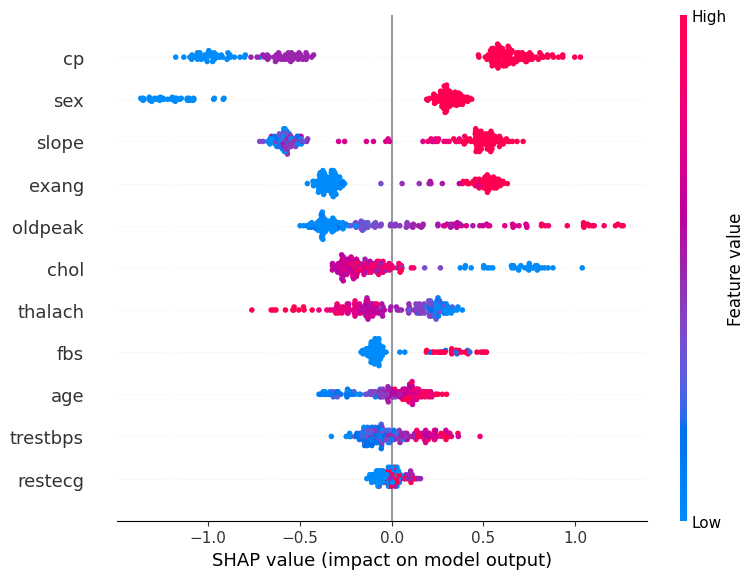


[Glass Box 2] Feature Importance (Proxy Random Forest)


/tmp/ipykernel_25875/918128212.py:58: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




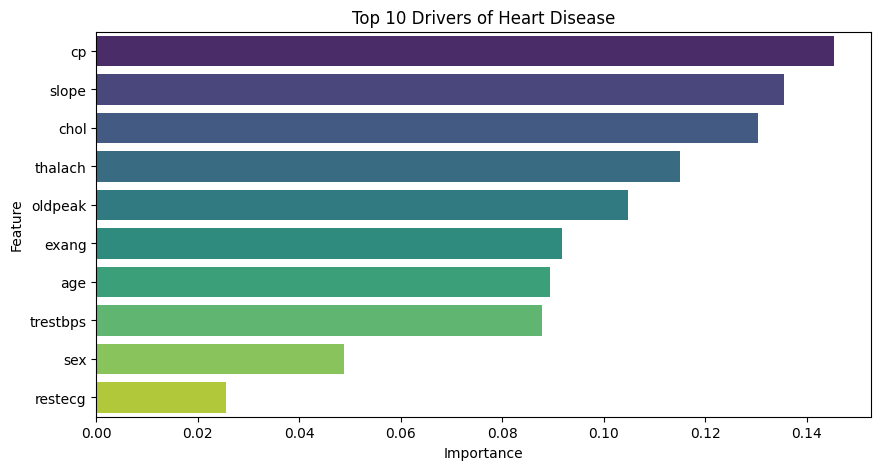

In [6]:
# ==========================================================
# 6. GLASS BOX EXPLAINABILITY (GLOBAL) - ROBUST VERSION
# ==========================================================
print("--- Generating SHAP Explanations ---")

# 1. SMART MODEL RETRIEVAL
# We need to find a tree-based model inside the winner to explain the logic.
# The names might change (e.g., 'cat', 'CatBoost', or maybe CatBoost isn't there!)
available_models = list(voting_clf.named_estimators_.keys())
print(f"Models available in the Champion Ensemble: {available_models}")

target_model = None
model_name_found = ""

# Priority Search: CatBoost > XGBoost > LightGBM > Random Forest
# We search for strings like "cat", "xgb", "forest" in the keys (case insensitive)
search_terms = ['cat', 'xgb', 'lgb', 'forest']

for term in search_terms:
    for key in available_models:
        if term in key.lower():
            target_model = voting_clf.named_estimators_[key]
            model_name_found = key
            break
    if target_model:
        break

if target_model is None:
    print("ERROR: No Tree-based model found in the Top 3 to generate SHAP plots.")
    print("Skipping SHAP visualization.")
else:
    print(f" Using '{model_name_found}' to explain the model's reasoning.")

    # 2. GENERATE SHAP VALUES
    # TreeExplainer works for CatBoost, XGBoost, LightGBM, and Random Forest
    try:
        explainer = shap.TreeExplainer(target_model)
        shap_values = explainer.shap_values(X_test_scaled)

        # 3. Summary Plot (Beeswarm)
        print("\n[Glass Box 1] SHAP Summary Plot (Global Feature Impact)")
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_test_scaled, show=False)
        plt.show()
    except Exception as e:
        print(f"Could not generate SHAP plot: {e}")

# 4. Feature Importance Bar Chart (Using a Fresh Random Forest)
# fit a fresh RF just for this visualization to ensure it works regardless of the ensemble
print("\n[Glass Box 2] Feature Importance (Proxy Random Forest)")
rf_proxy = RandomForestClassifier(n_estimators=100, random_state=42)
rf_proxy.fit(X_train_scaled, y_train)

feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf_proxy.feature_importances_})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Top 10 Drivers of Heart Disease")
plt.show()

7. Clinical interface

Processing Patient Data...

----------------------------------------
       AI ESTIMATIONS (IMPUTATION)
----------------------------------------
🔹 Missing 'trestbps' was estimated as: 136.60
----------------------------------------

       DIAGNOSTIC RESULT
 RESULT: HEALTHY (55.82%)

--- Why did the model make this decision? ---
(Using 'cat' to generate explanation)


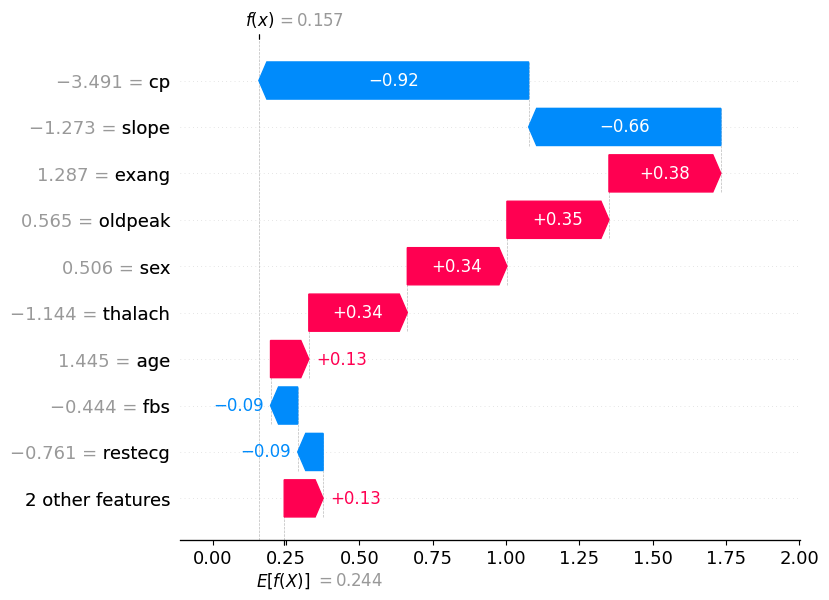


--- Textual Explanation ---
DECREASED RISK  by 0.92 due to: cp
DECREASED RISK  by 0.66 due to: slope
INCREASED RISK  by 0.38 due to: exang
INCREASED RISK  by 0.35 due to: oldpeak
INCREASED RISK  by 0.34 due to: sex


In [7]:
# ==========================================================
# 7. ROBUST CLINICAL INTERFACE (MANUAL TEST)
# ==========================================================
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. INPUT: ENTER PATIENT DATA HERE ---
new_patient = {
    'age': 67,
    'sex': 1,
    'cp': 0,            # Chest Pain
    'trestbps': np.nan, # <--- UNKNOWN (1)
    'chol': 286,
    'fbs': 0,
    'restecg': 0,
    'thalach': 108,
    'exang': 1,
    'oldpeak': 1.5,
    'slope': 1,
    'ca': 3,
    'thal': np.nan      # <--- UNKNOWN (2)
}

# --- 2. VALIDATION & PIPELINE ---
print("Processing Patient Data...")
df_manual = pd.DataFrame([new_patient])
missing_count = df_manual.isnull().sum().sum()

if missing_count > 4:
    print(f" ERROR: Too many missing values ({missing_count}).")
else:
    # A. Feature Engineering
    df_manual['age_thalach'] = df_manual['age'] * df_manual['thalach']
    df_manual['bp_chol'] = df_manual['trestbps'] * df_manual['chol']
    df_manual['stress_factor'] = df_manual['oldpeak'] * df_manual['slope']
    df_manual = df_manual[X.columns]

    # B. Impute
    df_manual_imp = imputer.transform(df_manual)

    # C. Scale
    df_manual_scaled = pd.DataFrame(scaler.transform(df_manual_imp), columns=X.columns)

    # --- 3. PREDICTION ---
    prediction = voting_clf.predict(df_manual_scaled)[0]
    probability = voting_clf.predict_proba(df_manual_scaled)[0][1]

    # --- 4. FEEDBACK ON IMPUTATION ---
    print("\n" + "-"*40)
    print("       AI ESTIMATIONS (IMPUTATION)")
    print("-" * 40)
    for col in df_manual.columns:
        if pd.isna(df_manual[col].values[0]):
            col_idx = df_manual.columns.get_loc(col)
            estimated_val = df_manual_imp[0][col_idx]
            print(f"🔹 Missing '{col}' was estimated as: {estimated_val:.2f}")
    print("-" * 40)

    # --- 5. RESULT ---
    print("\n" + "="*40)
    print("       DIAGNOSTIC RESULT")
    print("="*40)
    if prediction == 1:
        print(f" RESULT: HIGH RISK ({probability*100:.2f}%)")
    else:
        print(f" RESULT: HEALTHY ({ (1-probability)*100:.2f}%)")
    print("="*40 + "\n")

    # --- 6. EXPLANATION (SMART SEARCH) ---
    print("--- Why did the model make this decision? ---")

    # LOGIC FIX: Find a valid tree model inside the winner
    explainer_model = None
    found_name = ""

    # Get all sub-models in the champion
    available_models = voting_clf.named_estimators_

    # Search priorities (CatBoost > XGBoost > LightGBM > Random Forest)
    search_terms = ['cat', 'xgb', 'lgb', 'forest', 'tree']

    for term in search_terms:
        for name, model in available_models.items():
            if term in name.lower():
                explainer_model = model
                found_name = name
                break
        if explainer_model: break

    if explainer_model:
        print(f"(Using '{found_name}' to generate explanation)")
        try:
            explainer = shap.TreeExplainer(explainer_model)
            shap_values = explainer(df_manual_scaled)
            shap.plots.waterfall(shap_values[0])

            # Textual Explanation
            print("\n--- Textual Explanation ---")
            feature_names = df_manual_scaled.columns
            shap_contribs = shap_values[0].values

            # Sort by impact
            sorted_idx = np.argsort(np.abs(shap_contribs))[::-1]
            for idx in sorted_idx[:5]:
                feature = feature_names[idx]
                contrib = shap_contribs[idx]
                direction = "INCREASED RISK " if contrib > 0 else "DECREASED RISK "
                print(f"{direction} by {abs(contrib):.2f} due to: {feature}")

        except Exception as e:
            print(f"Could not generate SHAP plot: {e}")
    else:
        print("⚠️No Tree-based model found in the ensemble to generate Waterfall plot.")

8. final comparative visualization


--- Generating Final Comparisons ---


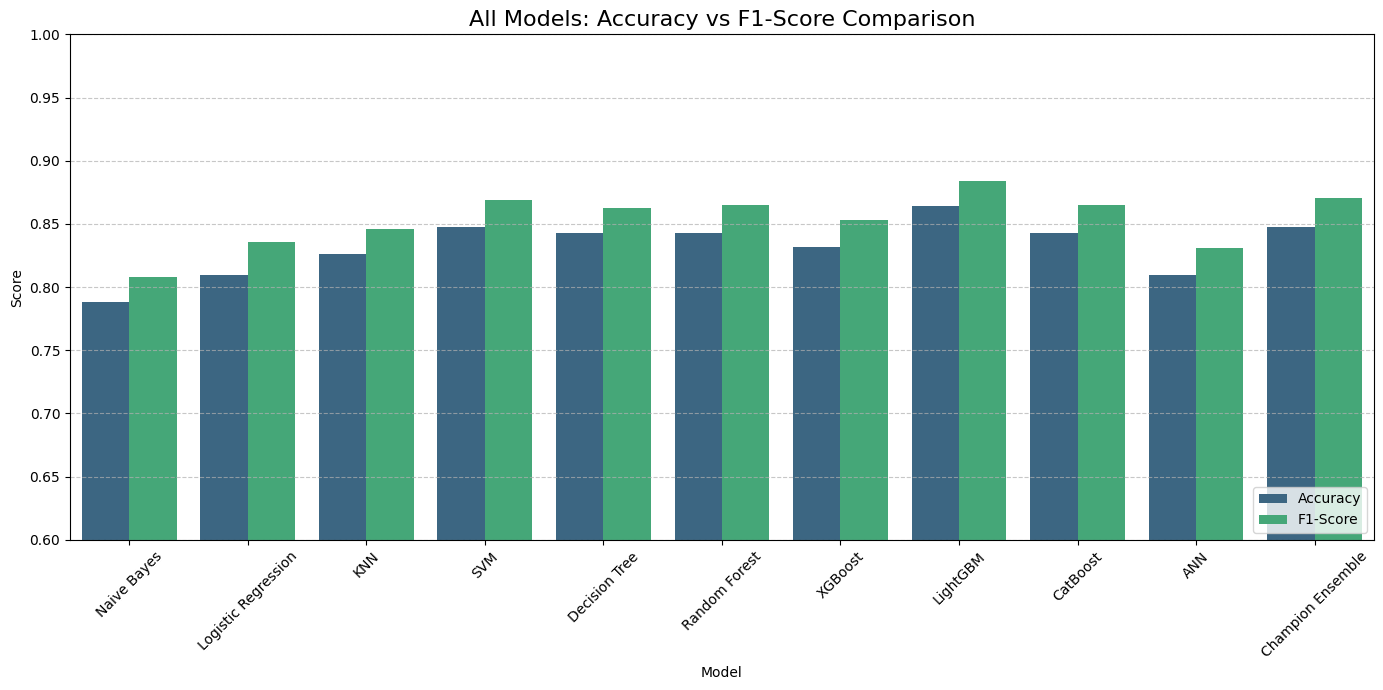


--- Generating Confusion Matrix Grid ---


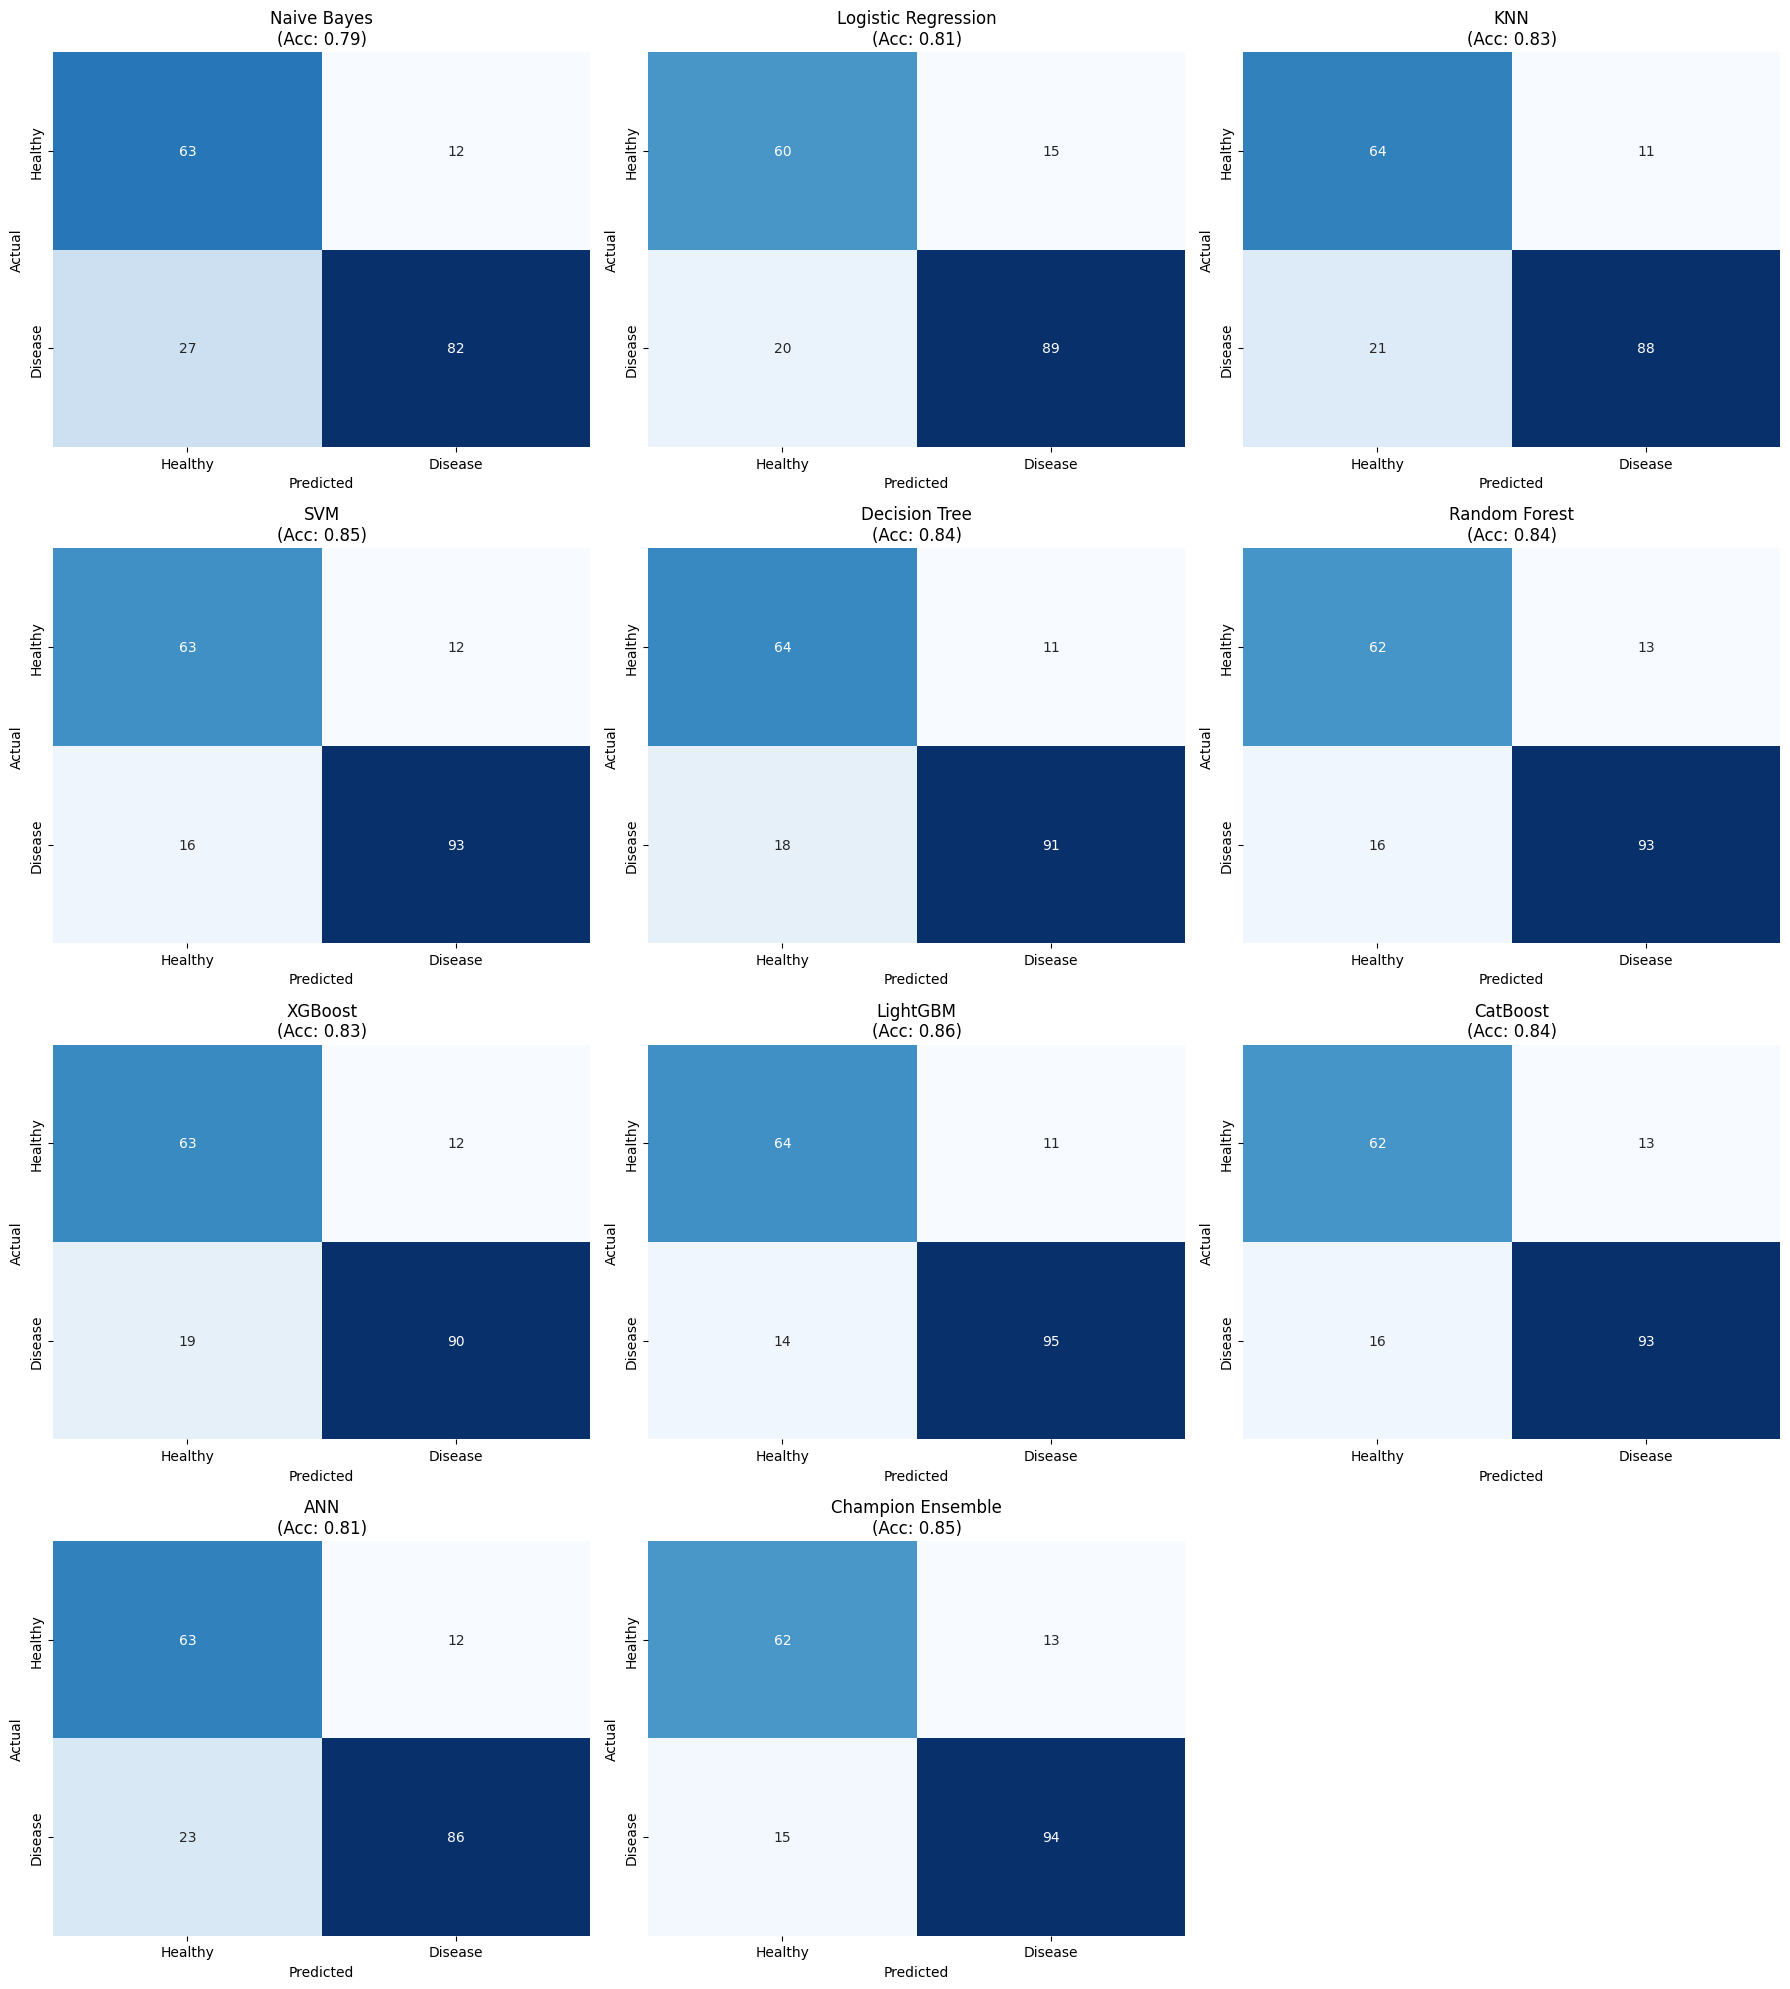

In [8]:
# ==========================================================
# 8. FINAL COMPARATIVE VISUALIZATIONS
# ==========================================================
print("--- Generating Final Comparisons ---")

# --- 1. GATHER ALL MODELS ---
# combine the individual ML models, the ANN, and the Champion Voting Model
all_models = models.copy()
all_models["ANN"] = ann
all_models["Champion Ensemble"] = voting_clf

# --- 2. PLOT A: ACCURACY vs F1-SCORE COMPARISON ---
# Recalculate metrics to ensure we have the latest data
comparison_data = []
for name, model in all_models.items():
    if name == "ANN":
        y_pred = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    comparison_data.append({"Model": name, "Metric": "Accuracy", "Score": acc})
    comparison_data.append({"Model": name, "Metric": "F1-Score", "Score": f1})

# Convert to DataFrame for plotting
df_comp = pd.DataFrame(comparison_data)

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(x="Model", y="Score", hue="Metric", data=df_comp, palette="viridis")
plt.title("All Models: Accuracy vs F1-Score Comparison", fontsize=16)
plt.ylim(0.6, 1.0) # Zoom in on the relevant range
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# --- 3. PLOT B: CONFUSION MATRIX GRID ---
print("\n--- Generating Confusion Matrix Grid ---")

# Determine grid size (e.g., 3 columns)
n_models = len(all_models)
cols = 3
rows = (n_models // cols) + (1 if n_models % cols > 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten() # Flatten to 1D array for easy looping

for i, (name, model) in enumerate(all_models.items()):
    # Get predictions
    if name == "ANN":
        y_pred = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_test_scaled)

    # Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot on the specific subplot (axes[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])

    axes[i].set_title(f"{name}\n(Acc: {accuracy_score(y_test, y_pred):.2f})")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Turn off any empty subplots if number of models isn't a perfect multiple of 3
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

--- Extracting Confusion Matrix Values for All Models ---

Detailed Confusion Matrix Breakdown:


,True Negatives (Healthy),False Positives (False Alarm),False Negatives (MISSED DIAGNOSIS),True Positives (Sick)
Model,,,,
LightGBM,64,11,14,95
Champion Ensemble,62,13,15,94
Random Forest,62,13,16,93
SVM,63,12,16,93
CatBoost,62,13,16,93
Decision Tree,64,11,18,91
XGBoost,63,12,19,90
Logistic Regression,60,15,20,89
KNN,64,11,21,88


<Figure size 1400x700 with 0 Axes>

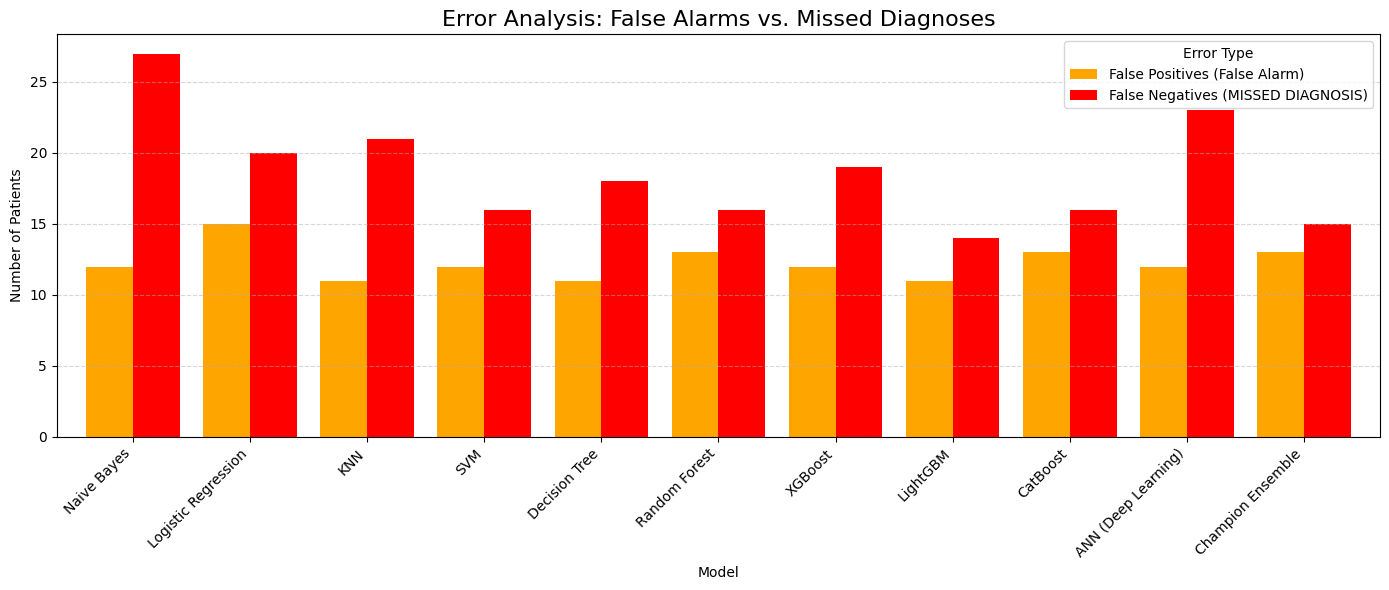

In [9]:
# ==========================================================
# 9. CONFUSION MATRIX VALUE COMPARISON (TN, FP, FN, TP)
# ==========================================================
print("--- Extracting Confusion Matrix Values for All Models ---")

# 1. Gather all models into one dictionary
all_models = models.copy()
all_models["ANN (Deep Learning)"] = ann
all_models["Champion Ensemble"] = voting_clf

cm_data = []

for name, model in all_models.items():
    # Get predictions
    if "ANN" in name:
        y_pred = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
    else:
        y_pred = model.predict(X_test_scaled)

    # Extract TN, FP, FN, TP using ravel()
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    cm_data.append({
        "Model": name,
        "True Negatives (Healthy)": tn,
        "False Positives (False Alarm)": fp,
        "False Negatives (MISSED DIAGNOSIS)": fn,
        "True Positives (Sick)": tp
    })

# 2. Create DataFrame
df_cm = pd.DataFrame(cm_data).set_index("Model")

# --- DISPLAY 1: THE NUMERICAL TABLE ---
print("\nDetailed Confusion Matrix Breakdown:")
display(df_cm.sort_values(by="False Negatives (MISSED DIAGNOSIS)", ascending=True))


# --- DISPLAY 2: VISUAL COMPARISON OF ERRORS ---
#  focus on the Errors (FP and FN) because accuracy hides these details.
error_df = df_cm[["False Positives (False Alarm)", "False Negatives (MISSED DIAGNOSIS)"]]

plt.figure(figsize=(14, 7))
error_df.plot(kind='bar', figsize=(14, 6), color=['orange', 'red'], width=0.8)
plt.title("Error Analysis: False Alarms vs. Missed Diagnoses", fontsize=16)
plt.ylabel("Number of Patients")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Error Type")
plt.tight_layout()
plt.show()

In [10]:
import joblib
from google.colab import files  # Library to help download files

print("--- Saving Champion Model & Tools ---")

# 1. Save the objects to disk (inside Colab)

joblib.dump(voting_clf, 'champion_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(imputer, 'imputer.pkl')

print(" Files saved successfully!")

# 2. Trigger Auto-Download to your computer
print(" Downloading files now...")
files.download('champion_model.pkl')
files.download('scaler.pkl')
files.download('imputer.pkl')

--- Saving Champion Model & Tools ---
 Files saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>